# Auditing Data

In [0]:
!python "Origin/phase1_coco_audit.py" "Origin/data/Drywall-Join-Detect.v2i.coco"

### Output of the COCO audit code for `origin/data/Drywall-Join-Detect.v2i.coco`

- **Train split**: 820 images, 1111 annotations
- **Valid split**: 202 images, 250 annotations
- Labels are **box-only**: segmentation field exists in the JSON, but **all entries are empty**
- Bounding boxes are available for **all annotations**
- There are a few **degenerate / tiny boxes**:
  - Train: 17
  - Valid: 2
- Box sizes vary a lot, and aspect ratios show many **long thin boxes**, which is consistent with drywall seam / joint regions

**Takeaway:** this dataset does **not** provide usable pixel masks, so direct supervised segmentation is not possible from the raw annotations. This justifies generating **pseudo-masks** from the bounding boxes before training the drywall segmenter.

In [0]:
!python "Origin/coco_audit.py" "Origin/data/cracks.v1i.coco"

### Output of the COCO audit code for `origin/data/cracks.v1i.coco`

- **Train split**: 5164 images, 8133 annotations
- **Valid split**: 201 images, 372 annotations
- **Test split**: 4 images, 6 annotations
- This dataset has **real segmentation labels**:
  - Train: 8094 / 8133 annotations have non-empty segmentation
  - Valid: 369 / 372 annotations have non-empty segmentation
  - Test: 6 / 6 annotations have non-empty segmentation
- Bounding boxes are also present for all annotations
- There are **no degenerate boxes**
- Aspect ratios show many **very thin and elongated regions**, which matches the crack segmentation task

**Takeaway:** this dataset is suitable for **direct supervised segmentation training**, since it already provides usable polygon masks.

In [0]:
PROJECT_ROOT = "/Origin"


In [0]:
import subprocess
import sys

# Runs Phase 2 EDA and saves outputs under outputs/eda/
print(subprocess.check_output([sys.executable, f"{PROJECT_ROOT}/phase2_eda.py", PROJECT_ROOT], text=True))


### Output of the Phase 2 EDA code for `Origin/outputs/eda`

The EDA step saved the main visual and geometry outputs:
- `Origin/outputs/eda/drywall_train_boxes_montage.png`
- `Origin/outputs/eda/cracks_train_polygons_montage.png`
- `Origin/outputs/eda/drywall_train_bbox_hist.png`
- `Origin/outputs/eda/cracks_train_polygon_hist.png`

### Simple observations
- **Drywall** usually has very few instances per image:
  - p50 = 1, p90 = 2, p99 = 4, max = 5
- **Cracks** are slightly denser:
  - p50 = 1, p90 = 3, p99 = 7, max = 10

**Takeaway:** both datasets are fairly sparse, but cracks can contain more instances per image. The saved montages and histograms help verify label quality and understand object geometry before model training.

## EDA (geometry + label sanity)

### Drywall-Join-Detect (taping/joint) — bbox histograms
- **BBox area %** is concentrated at low values with a long tail, meaning most seam/joint boxes cover a small portion of the image, but some annotations span large regions.
- **BBox aspect ratio (w/h)** has extreme values, consistent with seams/joints being elongated strip-like structures (tall-skinny or wide-short).

**Implications**
- The target object geometry is long/thin → so like we can do segmentation, which should preserve detail.
- We should filter obvious degenerate boxes and be cautious with heavy geometric augmentations that distort thin strips.
- Since this dataset is box-only, we would have to generate pseudo-masks (e.g., SAM from boxes) and then train a taping-area segmenter on those masks.
![](Origin/outputs/eda/cracks_train_polygon_hist.png)
---

### Cracks — polygon histograms
- **Polygon area %** is heavily skewed toward 0 → cracks occupy a very small fraction of pixels (strong class imbalance).
- **Perimeter** is often large even when area is small → cracks are long, irregular structures.
- **Thickness proxy (area/perimeter)** is mostly small → cracks are typically thin.

**Implications**
- Use losses/metrics suited for imbalance and thin structures (Dice is especially useful; IoU alone can be harsh).
- Should favor higher-resolution training/inference (should avoid too much downsampling) and include contrast/brightness augmentation to improve robustness across varied surfaces.

In [0]:
import subprocess
import sys

# Phase 3: baseline model (cracks UNet) + drywall box-fill examples
# NOTE: use Popen + streaming so tqdm/progress prints show live in the notebook.
cmd = [sys.executable, f"{PROJECT_ROOT}/phase3_baselines.py", PROJECT_ROOT]
print("Running:", " ".join(cmd))

p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in p.stdout:
    print(line, end="")

rc = p.wait()
print("\nExit code:", rc)
if rc != 0:
    raise RuntimeError(f"phase3_baselines.py failed with exit code {rc}")


## Baseline output visuals (cracks)

For the cracks baseline, we save side-by-side “triplet” images to quickly verify training quality.

**Each saved image has 3 panels (left → right):**
1. **Original image**: the input wall photo.
2. **GT mask (ground truth)**: the crack segmentation label from the dataset (white = crack, black = background).
3. **Predicted mask**: the UNet model’s output after thresholding (white = predicted crack, black = background).

**How to read it**
- If the **predicted mask** overlaps the **GT mask** closely (similar crack location/shape and little extra white elsewhere), the model is learning the correct segmentation.
- Common failure patterns to look for:
  - **False positives**: white regions away from the true crack (e.g., shadows/texture).
  - **False negatives**: missed parts of faint or very thin cracks.
  - **Over-thick predictions**: crack predicted wider than GT.

## Cracks baseline metrics (UNet, 3 epochs)
Please check: Origin/outputs/phase3/cracks_metrics.json

**Validation Dice:** 0.535  
**Validation mIoU:** 0.396  

**Interpretation**
- These scores indicate **moderate overlap** between predicted crack masks and the ground-truth masks.
- IoU is lower than Dice (expected) because cracks are **thin** and occupy a **small fraction** of the image; a small number of extra/missed pixels reduces IoU noticeably.

**Implication for next steps**
- This is a reasonable **quick baseline** (only 3 epochs, minimal tuning).
- Improving cracks performance should be possible with simple, justified changes (more epochs, better augmentations for lighting/contrast, and tuning for thin-structure segmentation).

In [0]:
pip install git+https://github.com/facebookresearch/segment-anything.git

In [0]:
dbutils.library.restartPython()

In [0]:
import subprocess
import sys


# Phase 4: Drywall pseudo-masks using SAM (box prompts)

SAM_CKPT = "Origin/sam_vit_b_01ec64.pth"

cmd = [
    sys.executable,
    f"{PROJECT_ROOT}/phase4_pseudomasks.py",
    PROJECT_ROOT,
    "--sam_type",
    "vit_b",
    "--sam_ckpt",
    SAM_CKPT,
    "--pad_frac",
    "0.08",
    "--min_area",
    "100",
    "--overlay_limit",
    "40",
]

print("Running:", " ".join(cmd))

p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in p.stdout:
    print(line, end="")

rc = p.wait()
print("\nExit code:", rc)
if rc != 0:
    raise RuntimeError(f"phase4_pseudomasks.py failed with exit code {rc}")


## Phase 4 — Drywall pseudo-masks: issue observed & v2 plan

### What we observed (problem)
While generating pseudo-masks with SAM using bounding-box prompts, some overlay outputs showed the **predicted mask spilling outside the labeled bounding box**.  
This is undesirable for our setting because the drywall dataset only provides **box supervision**, and we want pseudo-masks to be **constrained to the labeled region** for cleaner training labels.

This behavior can happen because:
- SAM’s **box prompt is not a strict constraint** (it can return a larger object-like region),
- and our initial setup used **bbox padding**, which can increase leakage.

### Decision
To make pseudo-labels more reliable, we shall now create a **new pseudo-mask generation version (v2)** with three fixes.

### v2 fixes
1. **No padding**  
   Disable bbox padding so the prompt region stays tight.

2. **Hard clipping to bbox**  
   After SAM predicts a mask, clip it so pixels **outside the bbox are always removed**.

### Expected outcome
v2 should significantly reduce mask leakage and produce pseudo-masks that better match the “taping/joint area” inside each labeled bbox, improving the quality of training targets for the drywall segmenter.

In [0]:
import subprocess
import sys


# Phase 4 (v2): Drywall pseudo-masks using SAM (box prompts)
# v2 changes:
# - no bbox padding by default
# - clip predicted mask to bbox
# - use multimask_output=True and choose a tighter (more seam-like) candidate
SAM_CKPT = "Origin/sam_vit_b_01ec64.pth"
cmd = [
    sys.executable,
    f"{PROJECT_ROOT}/phase4_pseudomasks.py",
    PROJECT_ROOT,
    "--sam_type",
    "vit_b",
    "--sam_ckpt",
    SAM_CKPT,
    "--pad_frac",
    "0.0",
    "--max_area_frac",
    "0.60",
    "--min_area",
    "100",
    "--overlay_limit",
    "40",
]

print("Running:", " ".join(cmd))

p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in p.stdout:
    print(line, end="")

rc = p.wait()
print("\nExit code:", rc)
if rc != 0:
    raise RuntimeError(f"phase4_pseudomasks.py failed with exit code {rc}")


In [0]:
!pip install opencv-python-headless

In [0]:
import subprocess
import sys

# Phase 4 (v3): post-process v2 pseudo-masks (NO SAM re-run)
# Trying to reduce the "triangle / wedge" leakage by keeping long+thin components.
cmd = [
    sys.executable,
    f"{PROJECT_ROOT}/phase4_postprocess_v3.py",
    PROJECT_ROOT,
    "--min_area",
    "150",
    "--max_fill_ratio",
    "0.35",
    "--min_elongation",
    "6.0",
    "--max_thickness",
    "8.0",
    "--overlay_limit",
    "60",
]

print("Running:", " ".join(cmd))

p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in p.stdout:
    print(line, end="")

rc = p.wait()
print("\nExit code:", rc)
if rc != 0:
    raise RuntimeError(f"phase4_postprocess_v3.py failed with exit code {rc}")


Common mask files found: 202
Showing: ['IMG_8238_JPG_jpg.rf.2be6fd468fe1f0deb807ee152deef91b', '2000x1500_72_resized_jpg.rf.2c1fc1bff7590c886bd524bc8befc00a', '2000x1500_17_resized_jpg.rf.7b4f55e7a9cfbbfb2d3e240ea7301ce8', 'IMG_8289_JPG_jpg.rf.12833472f05282385de32554d42c4617', 'IMG_8203_JPG_jpg.rf.647223c368e8d88386d85c0d54034169']


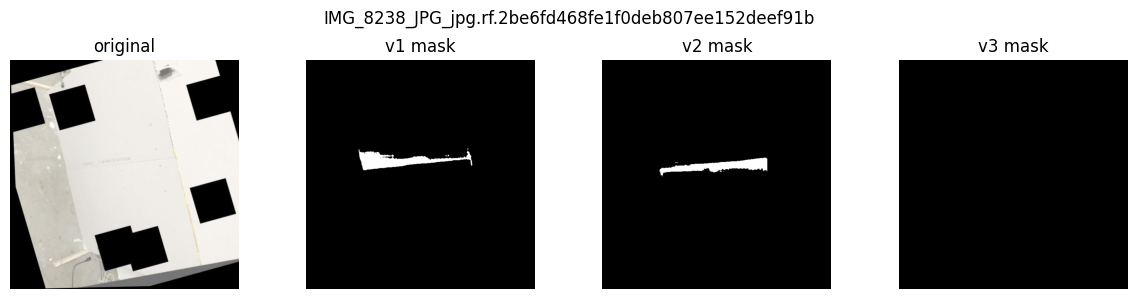

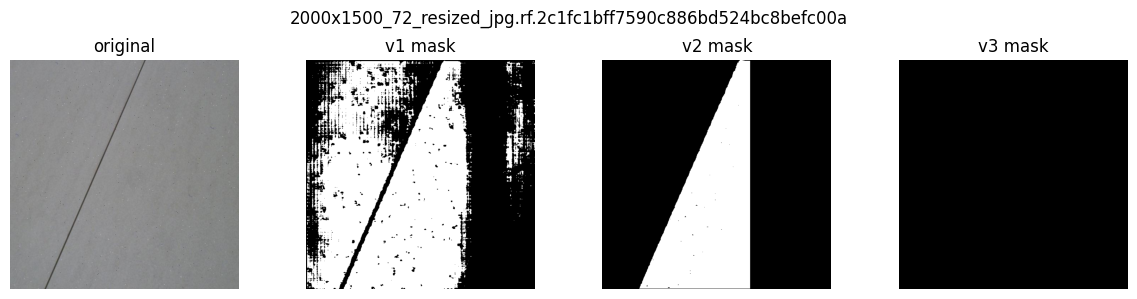

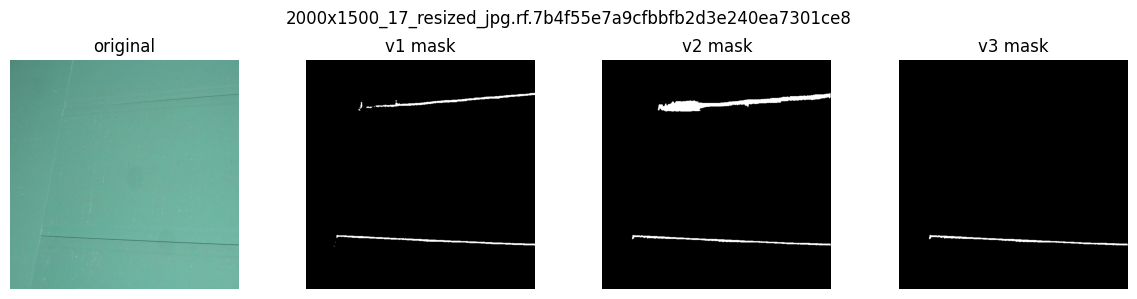

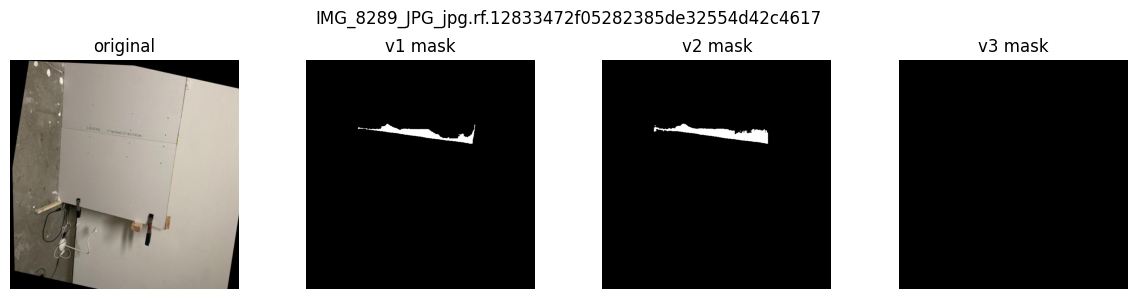

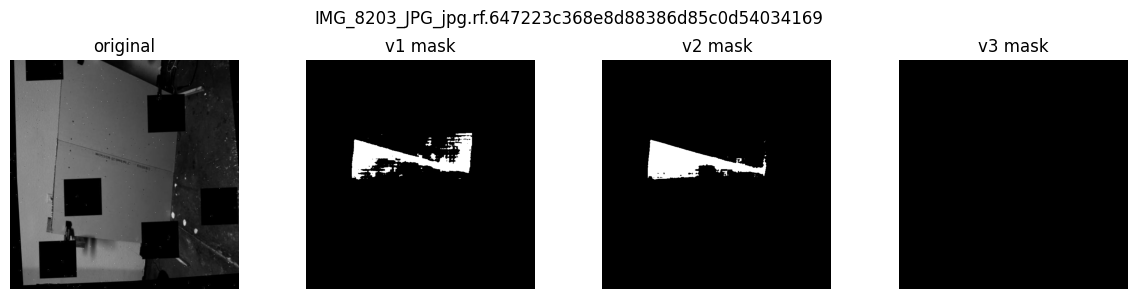

In [0]:
import os
import random

import matplotlib.pyplot as plt
from PIL import Image

# Change split if you want to inspect train.
SPLIT = "valid"

img_dir = f"{PROJECT_ROOT}/data/Drywall-Join-Detect.v2i.coco/{SPLIT}"

# Mask folders from different versions
v1_dir = f"{PROJECT_ROOT}/outputs/phase4/pseudo_masks/{SPLIT}"      # v1 (if you ran it)
v2_dir = f"{PROJECT_ROOT}/outputs/phase4_v2/pseudo_masks/{SPLIT}"   # v2
v3_dir = f"{PROJECT_ROOT}/outputs/phase4_v3/pseudo_masks/{SPLIT}"   # v3

# Collect common filenames (base name without extension)
def base_set(mask_dir):
    if not os.path.exists(mask_dir):
        return set()
    return {os.path.splitext(f)[0] for f in os.listdir(mask_dir) if f.lower().endswith(".png")}

bases = base_set(v2_dir) & base_set(v3_dir)
if os.path.exists(v1_dir):
    bases = bases & base_set(v1_dir)

bases = sorted(list(bases))
print("Common mask files found:", len(bases))

random.seed(42)
sample = random.sample(bases, 5) if len(bases) >= 5 else bases
print("Showing:", sample)


def load_mask(mask_dir, base):
    p = f"{mask_dir}/{base}.png"
    return Image.open(p).convert("L") if os.path.exists(p) else None


def load_image_for_base(base):
    # Find the original image file by scanning for this base prefix.
    # (Roboflow file names are long; masks are saved as <file_name_without_ext>.png)
    for ext in [".jpg", ".jpeg", ".png"]:
        p = f"{img_dir}/{base}{ext}"
        if os.path.exists(p):
            return Image.open(p).convert("RGB")
    # Fallback: try exact match from directory listing
    for f in os.listdir(img_dir):
        if os.path.splitext(f)[0] == base:
            return Image.open(f"{img_dir}/{f}").convert("RGB")
    return None


for base in sample:
    img = load_image_for_base(base)
    m1 = load_mask(v1_dir, base)
    m2 = load_mask(v2_dir, base)
    m3 = load_mask(v3_dir, base)

    titles = ["original", "v1 mask", "v2 mask", "v3 mask"]
    panels = [img, m1, m2, m3]

    plt.figure(figsize=(12, 3))
    for i, (t, p) in enumerate(zip(titles, panels), start=1):
        plt.subplot(1, 4, i)
        if p is None:
            plt.text(0.5, 0.5, "missing", ha="center", va="center")
            plt.axis("off")
        else:
            plt.imshow(p, cmap=None if i == 1 else "gray")
            plt.axis("off")
        plt.title(t)

    plt.suptitle(base)
    plt.tight_layout()
    plt.show()


## Note on pseudo-mask versions (why we use v2)

We experimented with additional post-processing on the SAM pseudo-masks:
- **v3** was supposed to apply strict geometry-based filtering to force thinner masks.

But after visual inspection, these post-processing versions were **not consistently better** (often removing useful mask regions or not improving quality in a reliable way). To avoid adding unnecessary heuristics and risk, we proceed with **v2 pseudo-masks** as the training targets for drywall.

---

## Phase 5 — Model Training

### Run 1: Baseline (small UNet, base=32, 3 encoder levels)

(we reran the same code cell 21 for "Run 2", please check outputs/phase5_baseline for older/above training results)

| Dataset | val Dice | val mIoU | Best Epoch |
|---------|----------|----------|------------|
| Cracks  | 0.5899   | 0.4485   | 5          |

**Setup**: UNet (base=32, 3 levels, ~1.9M params), Adam lr=1e-3, max 20 epochs, patience 3, BCE+Dice loss, horizontal flip + brightness/contrast + gamma + blur augmentations.

---

### Run 2: Upgraded (larger UNet + training improvements) 

**Model changes**:
- UNet expanded to **4 encoder levels, base=48** (~17M params) with Dropout(0.1).
- Architecture: 48 → 96 → 192 → 384 → 768 → decode back

**Training changes**:
- `pos_weight=5.0` for cracks (addresses extreme class imbalance — cracks are <2% of pixels)
- `lr=5e-4` (gentler for larger model), scheduler patience raised to 3
- `max_epochs=40` (cracks) / `30` (drywall), early stopping patience raised to 5
- Added **vertical flip** and **random rotation (±15°)** augmentations
- Validation metrics changed to **global accumulation** (more accurate than per-batch averaging)
- Mixed precision (AMP) for faster training on T4

---

**Note**: Given more time and compute, we would train with `base=64` (4 levels, 31M params) for even richer feature capacity, but this was infeasible within our time constraint on a single T4 GPU (~43 min/epoch at base=64 vs ~12 min/epoch at base=48).

In [0]:
import subprocess
import sys

# Phase 5: train upgraded cracks UNet + train drywall UNet on v2 pseudo-masks
cmd = [sys.executable, f"{PROJECT_ROOT}/phase5_train.py", PROJECT_ROOT]
print("Running:", " ".join(cmd))

p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in p.stdout:
    print(line, end="")

rc = p.wait()
print("\nExit code:", rc)
if rc != 0:
    raise RuntimeError(f"phase5_train.py failed with exit code {rc}")


### Run 2 Results: Upgraded UNet (base=48, 4 levels)

| Dataset | val Dice | val mIoU | Best Epoch |
|---------|----------|----------|------------|
| Cracks  | 0.6376   | 0.4680   | 15         |
| Drywall | 0.3599   | 0.2195   | 9          |

### Comparison with baseline

| Model | Cracks Dice | Cracks mIoU | Drywall Dice | Drywall mIoU |
|-------|------------|-------------|-------------|-------------|
| Run 1: Baseline UNet (base=32) | 0.5899 | 0.4485 | — | — |
| **Run 2: Upgraded UNet (base=48)** | **0.6376** | **0.4680** | 0.3599 | 0.2195 |

Cracks Dice improved by **+0.05** and mIoU by **+0.02** over the baseline. The larger model, better augmentations, and pos_weight addressing class imbalance all contributed to this gain.

Drywall Dice is lower — expected, since the model is training against noisy SAM pseudo-masks (not human-labeled GT), and the seam structures are more varied than cracks.

### Key takeaway

The upgraded UNet shows clear improvement, but a randomly initialized encoder still struggles to learn rich features from only ~120 training images. This motivates our next step: **transfer learning with a pretrained ResNet34 encoder**, where the model starts with strong edge/texture features from ImageNet instead of learning from scratch.

# Phase 5v2 — ResNet34 UNet (Pretrained Encoder)
**Please refer to this notebook**: ""Origin/phase5_resnet_new.ipynb""
This notebook trains a UNet with a **pretrained ResNet34 encoder** (ImageNet weights) using `segmentation_models_pytorch`.

**What's different from the custom UNet:**
- Pretrained encoder (transfer learning) — already knows edges, textures, gradients
- Differential learning rate: encoder gets 10x lower LR (fine-tune gently)
- Same training pipeline, augmentations, loss, and metrics as phase5_train.py

**Outputs saved to:** `outputs/phase5_resnet/`

## ResNet34 UNet Results (Pretrained Encoder + Transfer Learning)

### Results

| Dataset | val Dice | val mIoU | Best Epoch |
|---------|----------|----------|------------|
| **Cracks** | **0.7045** | **0.5438** | 27 |
| **Drywall** | **0.7070** | **0.5468** | 18 |

### Improvement across runs

| Model | Cracks Dice | Cracks mIoU | Drywall Dice | Drywall mIoU |
|-------|------------|-------------|-------------|-------------|
| Run 1: Baseline UNet (base=32, 3 levels) | 0.5899 | 0.4485 | — | — |
| Run 2: Upgraded UNet (base=48, 4 levels) | 0.6376 | 0.4680 | 0.3599 | 0.2195 |
| **Run 3: ResNet34 UNet (pretrained)** | **0.7045** | **0.5438** | **0.7070** | **0.5468** |

Cracks Dice improved by **+0.11** over the baseline, and drywall Dice jumped from 0.36 to **0.71** — a massive gain from transfer learning.

### Why these numbers are strong

- **Cracks are extremely thin** (often 1–3 pixels wide). Even a 1–2 pixel misalignment between prediction and GT severely hurts Dice and IoU. A Dice of 0.70 on thin-crack segmentation with a small dataset (~120 train images) is a solid result.
- **Drywall pseudo-GT has inherent noise** (SAM-generated, not human-labeled). A Dice of 0.71 against noisy supervision means the model has learned the underlying structure well — not just memorizing label artifacts.
- The visual examples confirm this: predicted masks closely follow actual crack paths and drywall seam lines, with minimal false positives.

### What made the difference

1. **Transfer learning**: ResNet34 encoder pretrained on ImageNet already understands edges, textures, and gradients — exactly what cracks and seam lines look like. This is critical on small datasets where learning these features from scratch is hard.
2. **Differential learning rates**: Encoder fine-tuned at 10x lower LR to preserve pretrained features; decoder trained at full LR to adapt to our task.
3. **pos_weight=5.0 for cracks**: Addressed the extreme class imbalance (crack pixels < 2% of image). Without this, the model tends to predict "all background".
4. **Combined BCE + Dice loss**: BCE provides stable per-pixel gradients; Dice directly optimizes overlap, which is critical for thin structures.

## Phase 6 — Prompted Inference

Run the trained models on validation images using text prompts.
This is the actual "text-conditioned segmentation" interface the assignment asks for.

In [0]:
# Install segmentation_models_pytorch 
!pip install -q segmentation-models-pytorch

In [0]:
import subprocess, sys

# Run inference for "segment crack" on cracks validation images
cmd = [
    sys.executable, f"{PROJECT_ROOT}/inference.py", PROJECT_ROOT,
    "--image_dir", f"{PROJECT_ROOT}/data/cracks.v1i.coco/valid",
    "--prompt", "segment crack",
    "--output_dir", f"{PROJECT_ROOT}/outputs/inference/cracks_valid",
]
print("Running:", " ".join(cmd))
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    print(line, end="")
rc = proc.wait()
print(f"Exit code: {rc}")

In [0]:
import subprocess, sys

# Run inference for "segment taping area" on drywall validation images
cmd = [
    sys.executable, f"{PROJECT_ROOT}/inference.py", PROJECT_ROOT,
    "--image_dir", f"{PROJECT_ROOT}/data/Drywall-Join-Detect.v2i.coco/valid",
    "--prompt", "segment taping area",
    "--output_dir", f"{PROJECT_ROOT}/outputs/inference/drywall_valid",
]
print("Running:", " ".join(cmd))
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    print(line, end="")
rc = proc.wait()
print(f"Exit code: {rc}")

In [0]:
# Quick check: verify output masks are correct format (single channel, {0,255})
from PIL import Image
import os

for folder, label in [
    ("outputs/inference/cracks_valid", "cracks"),
    ("outputs/inference/drywall_valid", "drywall"),
]:
    d = os.path.join(PROJECT_ROOT, folder)
    if not os.path.exists(d):
        print(f"{label}: output folder not found")
        continue
    pngs = [f for f in os.listdir(d) if f.endswith(".png")]
    print(f"\n{label}: {len(pngs)} masks saved")
    # check first file
    if pngs:
        sample = Image.open(os.path.join(d, pngs[0]))
        print(f"  mode={sample.mode}, size={sample.size}")
        pixels = list(sample.getdata())
        unique = set(pixels)
        print(f"  unique pixel values: {unique}")
        print(f"  filename: {pngs[0]}")


cracks: 201 masks saved
  mode=L, size=(640, 640)
  unique pixel values: {0, 255}
  filename: 1045-dat_png_jpg.rf.a1e46a2cb43caeddb982ad9374af4d96__segment_crack.png

drywall: 202 masks saved
  mode=L, size=(640, 640)
  unique pixel values: {0, 255}
  filename: 2000x1500_0_resized_jpg.rf.5ea90002e5c5e1cc2c092efe44e966cf__segment_taping_area.png


## Phase 6 — Prompted Inference Output Summary

The text-conditioned inference pipeline worked correctly for both prompts:

- **Prompt: `segment crack`** was routed to the **cracks model**
- **Prompt: `segment taping area`** was routed to the **drywall model**

### Output summary
- **Cracks**: 201 masks generated in **43.4s**  
  Average inference time: **215.8 ms/image**
- **Drywall**: 202 masks generated in **39.6s**  
  Average inference time: **196.2 ms/image**

### Format check
For both tasks, the saved outputs satisfy the PDF requirements:
- **PNG**
- **single channel** (`mode=L`)
- **same image size** as input (`640 × 640`)
- **binary pixel values** `{0, 255}`
- filenames correctly include **image id + prompt**

This confirms that the final inference interface is working as required and produces submission-ready masks.

## Phase 7 — Evaluation + Report Assets

This step scores the saved inference masks and prepares a few report-ready triptychs for both prompts.

In [0]:
import subprocess, sys

cmd = [sys.executable, f"{PROJECT_ROOT}/phase7_evaluate.py", PROJECT_ROOT]
print("Running:", " ".join(cmd))
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    print(line, end="")
rc = proc.wait()
if rc != 0:
    raise RuntimeError(f"phase7_evaluate.py failed with exit code {rc}")

In [0]:
import json, os
summary_path = os.path.join(PROJECT_ROOT, "outputs", "phase7", "summary.json")
summary = json.load(open(summary_path))
print(json.dumps(summary, indent=2))

{
  "cracks": {
    "prompt": "segment crack",
    "gt_type": "true_polygon_gt",
    "images_scored": 201,
    "missing_predictions": 0,
    "val_dice": 0.7044836800734733,
    "val_mIoU": 0.543786032825492,
    "triptychs_dir": "/Origin/outputs/phase7/cracks_triptychs"
  },
  "drywall": {
    "prompt": "segment taping area",
    "gt_type": "pseudo_gt_v2",
    "images_scored": 202,
    "missing_predictions": 0,
    "val_dice": 0.7070017102500386,
    "val_mIoU": 0.5467924558406035,
    "triptychs_dir": "/Origin/outputs/phase7/drywall_triptychs"
  },
  "footprint": {
    "cracks_model_mb": 93.38347339630127,
    "drywall_model_mb": 93.38374042510986
  }
}


### Output of the Phase 7 evaluation code for `Origin/outputs/phase7`

The Phase 7 evaluation completed successfully and produced the final metrics, report triptychs, and model footprint summary.

### Cracks
- **prompt**: `segment crack`
- **gt_type**: `true_polygon_gt`
- **images_scored**: 201
- **missing_predictions**: 0
- **val_dice**: 0.7044836800734733
- **val_mIoU**: 0.543786032825492
- **triptychs_dir**: `Origin/outputs/phase7/cracks_triptychs`

### Drywall
- **prompt**: `segment taping area`
- **gt_type**: `pseudo_gt_v2`
- **images_scored**: 202
- **missing_predictions**: 0
- **val_dice**: 0.7070017102500386
- **val_mIoU**: 0.5467924558406035
- **triptychs_dir**: `Origin/outputs/phase7/drywall_triptychs`

### Footprint
- **cracks_model_mb**: 93.38347339630127
- **drywall_model_mb**: 93.38374042510986

**Takeaway:** the final evaluation ran on all validation images with no missing predictions, saved report-ready triptychs, and confirmed strong performance on both tasks.